# L1.2 — Gradient Descent

Hands-on notebook for the lesson [`1-2-gradient-descent.mdx`](../../llm-quest-theory/level-1/1-2-gradient-descent.mdx).

> **Learning objectives**
> - Implement gradient descent from scratch on a 1D problem and a 2D problem.
> - Visualize the trajectory on a loss surface and see why GD can zig-zag.
> - Compare Batch GD, SGD, and Mini-batch GD on a linear regression problem.

## Connection to the theory
Covers **§1–§7** of the source `.mdx`. The update rule is one line — `theta <- theta - eta * grad` — and every ML model you will train later is a scaled-up version of this.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. GD on a 1D problem
Minimize `f(x) = (x - 3)^2`. Analytic gradient: `f'(x) = 2 (x - 3)`. Optimal `x = 3`.

In [2]:
def f(x):  return (x - 3) ** 2
def df(x): return 2 * (x - 3)

def gd_1d(x0, lr, n_steps):
    xs = [x0]
    x = x0
    for _ in range(n_steps):
        x = x - lr * df(x)
        xs.append(x)
    return np.array(xs)

traj = gd_1d(x0=-4.0, lr=0.1, n_steps=40)
print(f"Final x = {traj[-1]:.4f}  (expected 3.0)")
print(f"Final f(x) = {f(traj[-1]):.4f}")

Final x = 2.9991  (expected 3.0)
Final f(x) = 0.0000


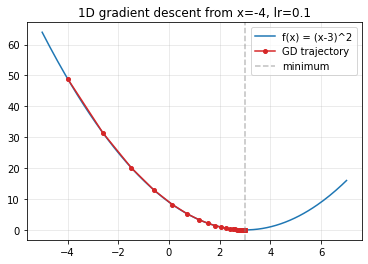

In [3]:
xs_plot = np.linspace(-5, 7, 200)
fig, ax = plt.subplots()
ax.plot(xs_plot, f(xs_plot), color="tab:blue", label="f(x) = (x-3)^2")
ax.plot(traj, f(traj), "o-", color="tab:red", markersize=4, label="GD trajectory")
ax.axvline(3.0, linestyle="--", color="gray", alpha=0.5, label="minimum")
ax.grid(alpha=0.3); ax.legend(); ax.set_title("1D gradient descent from x=-4, lr=0.1")
plt.show()

## 2. GD on a 2D anisotropic bowl

$$f(x, y) = \tfrac{1}{2}(x^2 + 3 y^2)$$

The `y` axis has higher curvature than the `x` axis — gradient descent with a shared learning rate will zig-zag.

In [4]:
def f2(v):
    x, y = v
    return 0.5 * (x ** 2 + 3 * y ** 2)

def grad2(v):
    x, y = v
    return np.array([x, 3 * y])

def gd_2d(v0, lr, n_steps):
    vs = [v0.copy()]
    v = v0.copy()
    for _ in range(n_steps):
        v = v - lr * grad2(v)
        vs.append(v.copy())
    return np.array(vs)

traj_slow  = gd_2d(np.array([-3.0, 2.0]), lr=0.05, n_steps=60)
traj_fast  = gd_2d(np.array([-3.0, 2.0]), lr=0.5,  n_steps=60)
traj_explode = gd_2d(np.array([-3.0, 2.0]), lr=0.7, n_steps=20)
print("lr=0.05 final  :", traj_slow[-1])
print("lr=0.5  final  :", traj_fast[-1])
print("lr=0.7  final  :", traj_explode[-1], "  (diverged)")

lr=0.05 final  : [-1.38209397e-01  1.16456984e-04]
lr=0.5  final  : [-2.60208521e-18  1.73472348e-18]
lr=0.7  final  : [-1.04603532e-10  1.34549999e+01]   (diverged)


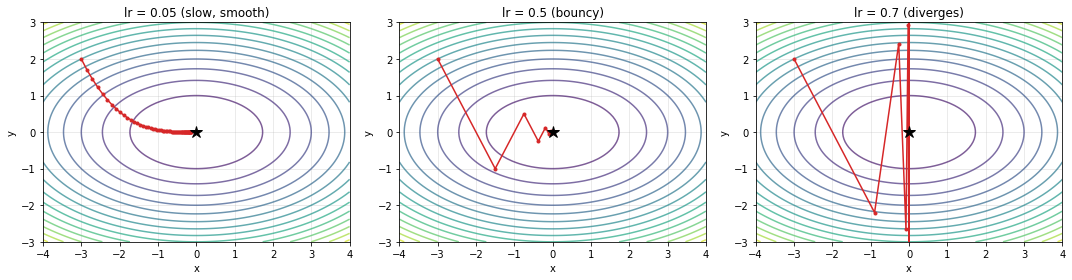

In [5]:
xx = np.linspace(-4, 4, 80)
yy = np.linspace(-3, 3, 80)
XX, YY = np.meshgrid(xx, yy)
ZZ = 0.5 * (XX ** 2 + 3 * YY ** 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t_, title in zip(
    axes,
    [traj_slow, traj_fast, traj_explode],
    ["lr = 0.05 (slow, smooth)", "lr = 0.5 (bouncy)", "lr = 0.7 (diverges)"]
):
    ax.contour(XX, YY, ZZ, levels=20, cmap="viridis", alpha=0.7)
    ax.plot(t_[:, 0], t_[:, 1], "o-", color="tab:red", markersize=3)
    ax.plot(0, 0, "k*", markersize=12)
    ax.set_title(title); ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_xlim(-4, 4); ax.set_ylim(-3, 3); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. GD on a real linear regression problem
Synthesize `y = 2.5 x + 1.0 + noise` and fit by gradient descent on MSE.

In [6]:
N = 200
x = np.random.uniform(-2, 2, N)
y = 2.5 * x + 1.0 + np.random.normal(0, 0.3, size=N)

def lr_loss(a, b):
    return float(np.mean((a * x + b - y) ** 2))

def lr_grad(a, b):
    err = a * x + b - y
    return 2 * np.mean(err * x), 2 * np.mean(err)

def fit_full_batch(lr=0.05, n_epochs=80):
    a, b = 0.0, 0.0
    history = []
    for ep in range(n_epochs):
        da, db = lr_grad(a, b)
        a -= lr * da
        b -= lr * db
        history.append(lr_loss(a, b))
    return (a, b), history

(a_full, b_full), hist_full = fit_full_batch()
print(f"Batch GD final: a={a_full:.3f}, b={b_full:.3f}, loss={hist_full[-1]:.4f}")

Batch GD final: a=2.494, b=1.020, loss=0.0840


## 4. Compare Batch GD, SGD, Mini-batch GD
Same problem, same number of gradient evaluations (roughly), but different granularity.

In [7]:
def fit_sgd(lr=0.05, n_epochs=10, batch_size=1):
    a, b = 0.0, 0.0
    history = []
    idx = np.arange(N)
    for ep in range(n_epochs):
        np.random.shuffle(idx)
        for start in range(0, N, batch_size):
            bi = idx[start:start + batch_size]
            err = a * x[bi] + b - y[bi]
            da = 2 * np.mean(err * x[bi])
            db = 2 * np.mean(err)
            a -= lr * da
            b -= lr * db
            history.append(lr_loss(a, b))
    return (a, b), history

(a_sgd,  b_sgd),  hist_sgd  = fit_sgd(batch_size=1,  n_epochs=10)
(a_mini, b_mini), hist_mini = fit_sgd(batch_size=16, n_epochs=10)
print(f"SGD    final: a={a_sgd:.3f},  b={b_sgd:.3f},  loss={hist_sgd[-1]:.4f}")
print(f"Mini16 final: a={a_mini:.3f}, b={b_mini:.3f}, loss={hist_mini[-1]:.4f}")
print(f"Batch  final: a={a_full:.3f}, b={b_full:.3f}, loss={hist_full[-1]:.4f}")

SGD    final: a=2.402,  b=1.022,  loss=0.0957
Mini16 final: a=2.509, b=1.021, loss=0.0844
Batch  final: a=2.494, b=1.020, loss=0.0840


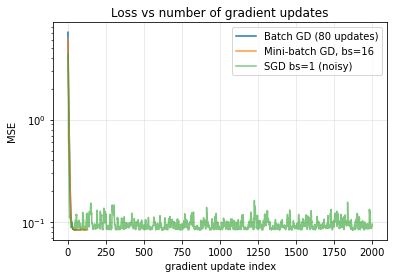

In [8]:
fig, ax = plt.subplots()
ax.plot(hist_full, label="Batch GD (80 updates)")
ax.plot(hist_mini, label="Mini-batch GD, bs=16", alpha=0.8)
ax.plot(hist_sgd,  label="SGD bs=1 (noisy)", alpha=0.6)
ax.set_xlabel("gradient update index"); ax.set_ylabel("MSE")
ax.set_yscale("log"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Loss vs number of gradient updates")
plt.show()

Observations:
- Batch GD is smoothest but uses the full dataset for every step.
- Pure SGD is noisy but reaches a similar minimum.
- Mini-batch GD keeps most of the stability while still being cheap per step — that is why it is the default everywhere today.

## 5. Quick checks

In [9]:
assert abs(traj[-1] - 3.0) < 1e-3, "1D GD should converge to x=3"
assert np.linalg.norm(traj_slow[-1]) < 0.5, "2D GD (lr=0.05) should be close to origin"
assert np.linalg.norm(traj_explode[-1]) > 10, "lr=0.7 should diverge on this problem"
assert abs(a_full - 2.5) < 0.1 and abs(b_full - 1.0) < 0.1
print("OK — gradient descent behaves as expected.")

OK — gradient descent behaves as expected.


## Reflection questions

1. On the anisotropic bowl, why does vanilla GD zig-zag even with a well-chosen learning rate? What would momentum or Adam change?
2. Why does SGD sometimes *help* escape bad local minima, while batch GD can get stuck?
3. If we doubled the dataset size in section 3, how would `hist_full` vs `hist_mini` change? Think about both cost per step and noise.

## References
- Source theory: [`1-2-gradient-descent.mdx`](../../llm-quest-theory/level-1/1-2-gradient-descent.mdx)
- Next: [`1-3-learning-rate`](1-3-learning-rate.ipynb)